# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering

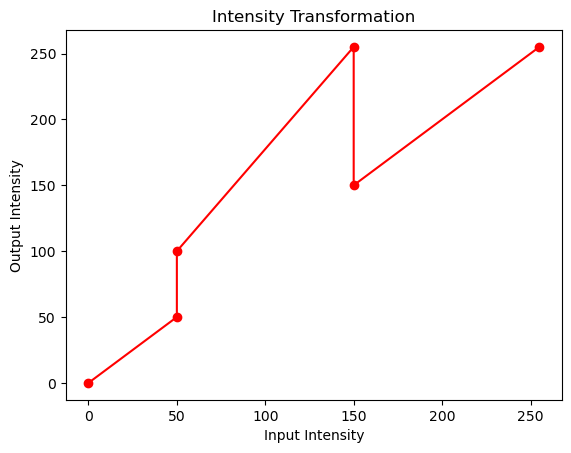

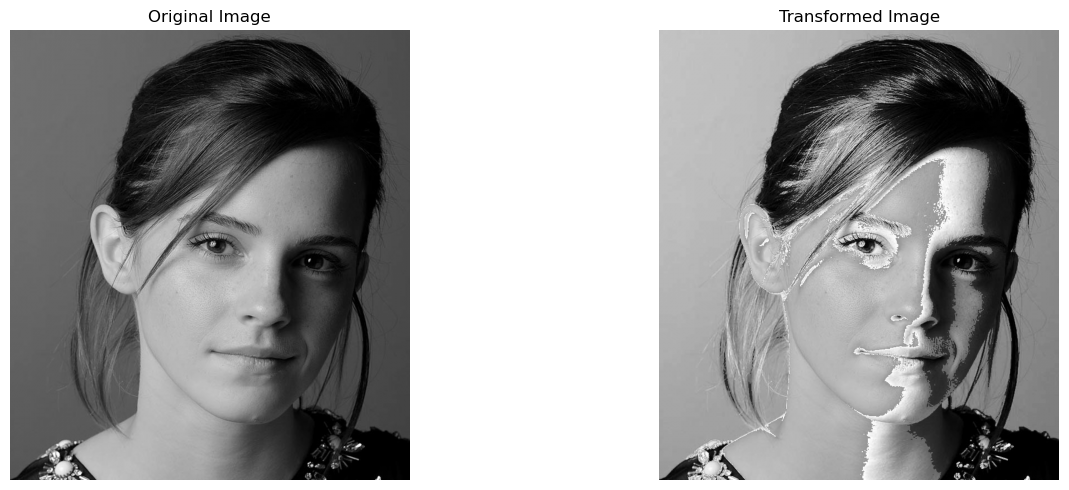

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    lut = np.interp(np.arange(256), x, y)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    transformed_im = lut[im]
    
    return transformed_im

eps = 1e-5
breakpoints = np.array([
    [0,0],
    [50,50],
    [50+eps,100],
    [150,255],
    [150+eps,150],
    [255,255],
])

im1 = cv2.imread('Images/emma.jpg', cv2.IMREAD_GRAYSCALE)
assert im1 is not None

intensity_transformed_im1 = intensity_transform(im1, breakpoints)

plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.title('Intensity Transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(im1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(intensity_transformed_im1, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

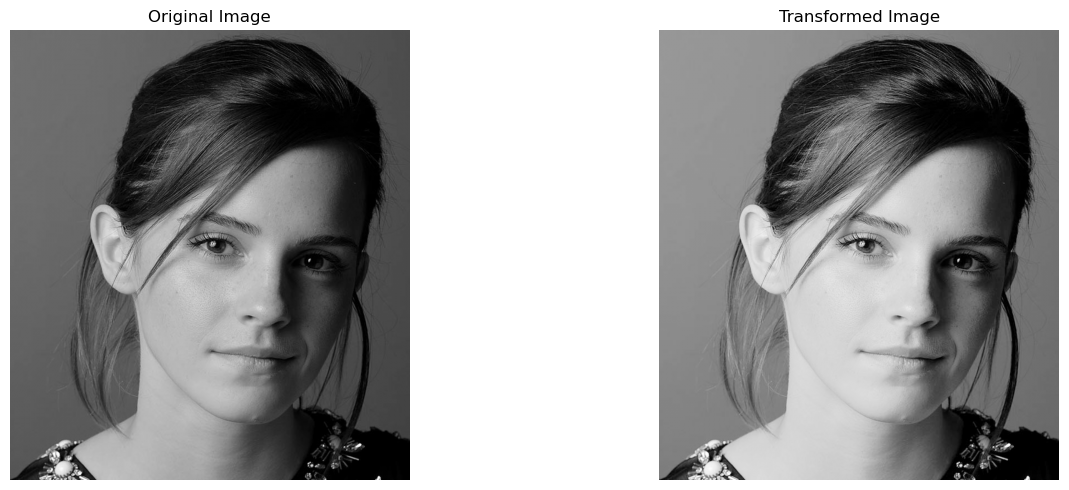

In [3]:
breakpoints_new = np.array([
    [0, 0],
    [60, 100],
    [160, 200],
    [255, 255]
])

intensity_transformed_im1 = intensity_transform(im1, breakpoints_new)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(im1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(intensity_transformed_im1, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

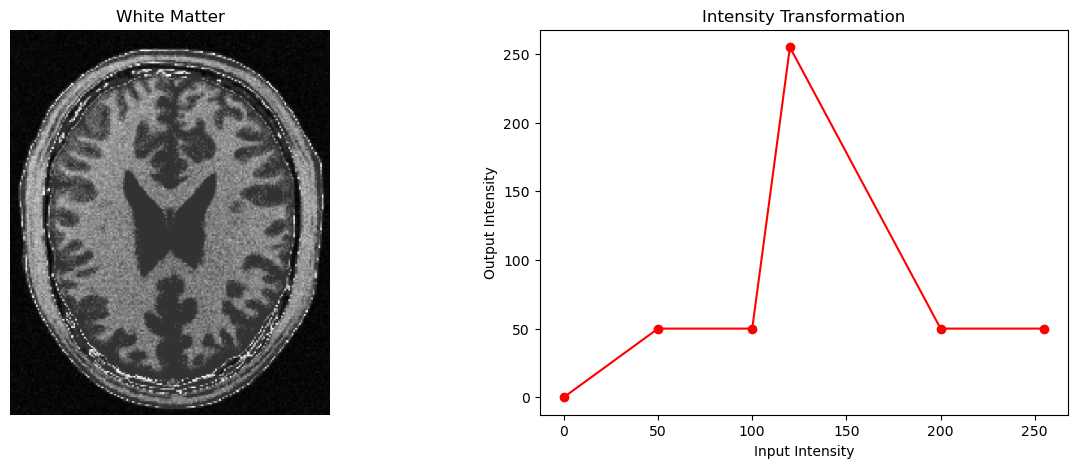

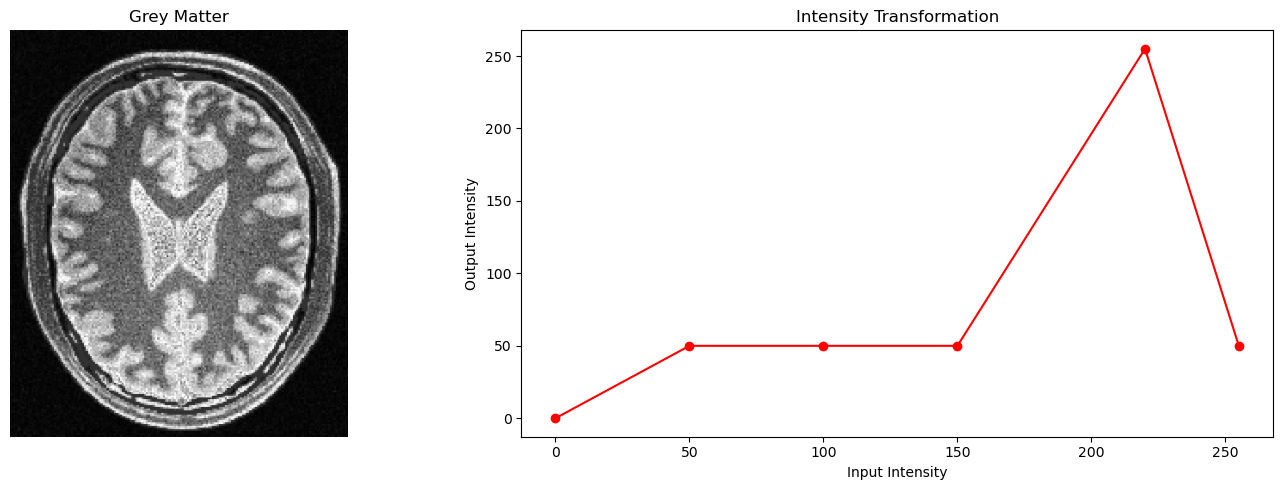

In [4]:
im2 = cv2.imread('Images/brain.png', cv2.IMREAD_GRAYSCALE)
assert im2 is not None

breakpoints_white = np.array([
    [0, 0],
    [50, 50],
    [100, 50],
    [120, 255],
    [200, 50],
    [255, 50],
])

breakpoints_grey = np.array([
    [0, 0],
    [50, 50],
    [100, 50],
    [150, 50],
    [220, 255],
    [255, 50],
])

white_matter = intensity_transform(im2, breakpoints_white)
grey_matter = intensity_transform(im2, breakpoints_grey)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(white_matter, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("White Matter")
axes[0].axis("off")

axes[1].plot(breakpoints_white[:, 0], breakpoints_white[:, 1], 'ro-')
axes[1].set_xlabel('Input Intensity')
axes[1].set_ylabel('Output Intensity')
axes[1].set_title('Intensity Transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(grey_matter, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Grey Matter")
axes[0].axis("off")

axes[1].plot(breakpoints_grey[:, 0], breakpoints_grey[:, 1], 'ro-')
axes[1].set_xlabel('Input Intensity')
axes[1].set_ylabel('Output Intensity')
axes[1].set_title('Intensity Transformation')
plt.tight_layout()
plt.show()

In [ ]:
im3 = cv2.imread('Images/feet.jpeg', cv2.IMREAD_COLOR)
assert im3 is not None

im3_lab = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)

def gamma_correction(image, gamma):
    return ((image/255)**gamma) * 255


